<br>

<div align="center">
<h1>Использование языка программирования Julia для решения математических задач
<br> 
<br> 
Часть II</h1>
</div>

<br>

<br>

<br>

<br>

<br>

<br>


<br>

**<span style="font-size: 1.1em">Авторы:</span>** 

**Чуракова Юлия Романовна**  
*Студентка факультета математики и компьютерных наук*  
*Кубанского Государственного Университета*

**<span style="font-size: 1.1em"></span>** **Алексеев Евгений Ростиславович**  
*Кандидат технических наук, доцент*  
*Доцент кафедры информационных технологий*  
*Кубанского Государственного Университета*


<br>

<br>

<br>

<br>

<br>

<br>

<br>

---


**Полная версия пособия доступна в репозитории:** [https://github.com/JuliaChurakova/Julia](https://github.com/JuliaChurakova/Julia)

---

# Литература
1. Алексеев, Е. Р. Scilab: Решение инженерных и математических задач: учеб. издание. / Е.Р. Алексеев, К. В. Дога, О. В. Чеснокова М. – Базальт СПО; ДМК Пресс, 2024. – 440 с.
2. Балакин, А. А. Численные методы и математическое моделирование: Учебное пособие / А.А. Балакин. – Долгопрудный: Издательский Дом «Интеллект», 2022. – 288 с.
3. Деза, Е. И. Введение в криптографию: Теоретико-числовые основы защиты информации. Учебное пособие / Е. И. Деза, Л. В. Котова. – Москва: ЛЕНАНД, 2022. – 376 с.
4. Кнауб, Л. В. Теоретико-численные методы в криптографии / Л. В. Кнауб, Е. А. Новиков, Ю. А. Шитов; Сибирский федеральный университет – Красноярск: 2011. – 160 с.

# Глава 18 Численное интегрирование

Для непрерывной функции $f(x)$ на интервале $[a, b]$ с известной первообразной $F(x)$ определенный интеграл вычисляется по формуле:

$$
\int_a^b f(x)dx = F(b) - F(a)
$$

Однако на практике часто возникают ситуации, когда:
- первообразная не выражается через элементарные функции;
- подынтегральная функция задана таблично или графически;
- вычисление первообразной слишком сложно.

В таких случаях применяют численные методы интегрирования (называемые механическими квадратурами), основанные на приближенном вычислении площади под кривой, которая геометрически интерпретирует значение интеграла.

## 18.1 Метод трапеций

При численном интегрировании методом трапеций отрезок $[a, b]$ разбивают на $n$ равных частей точками:

$$x_0 = a, x_1, x_2, ..., x_n = b,$$ 

с шагом $h = \frac{b-a}{n}$.

Где координаты точек разбиения вычисляются по формуле:
$$x_i = x_0 + ih, \quad i = 1, 2, ..., n-1$$

Геометрически метод заключается в замене площади под кривой $y = f(x)$ суммой площадей прямолинейных трапеций:
1. в каждой точке $x_i$ вычисляют значение функции $f(x_i)$;
2. соединяют соседние точки $(x_{i-1}, f(x_{i-1}))$ и $(x_{i}, f(x_{i}))$ прямыми линиями;
3. площадь каждой трапеции вычисляется как:
$$S_i = \frac{h}{2}(f(x_{i-1}) + f(x_{i})),$$

следовательно, площадь искомой фигуры вычисляют по формуле:
$$\int_a^b f(x)dx = \sum_{i=1}^{n}S_i = \frac{h}{2}\sum_{i=1}^{n}f(x_{i-1}) + f(x_i) = h\left( \frac{f(x_{0}) + f(x_{n})}{2} + \sum_{i=1}^{n-1}f(x_i) \right),$$

где:
- $h$ – шаг разбиения;
- $x_0, x_1, ..., x_n$ – точки разбиения отрезка;
- $f(x_i)$ – значения функции в точках разбиения.

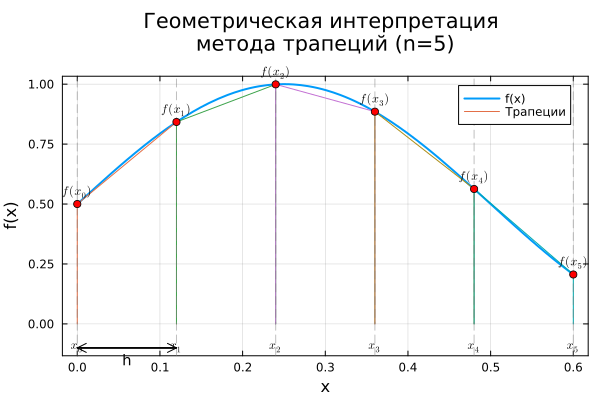

In [11]:
using Plots  

function plot_trapezoid_interpretation(f, a, b, n)
    # Вычисляем точки разбиения
    h = (b - a) / n
    x = range(a, b, length=n+1)
    y = f.(x)
    

    p = plot(f, a, b, linewidth=2, label="f(x)", legend=:topright, title="Геометрическая интерпретация 
метода трапеций (n=$n)
        
        ", xlabel="x", ylabel="f(x)", framestyle=:box)
    
    # Рисуем трапеции
    for i in 1:n
        plot!([x[i], x[i], x[i+1], x[i+1]], [0, y[i], y[i+1], 0], fillalpha=0.3, linewidth=1, label=i==1 ? "Трапеции" : "")
    end
    

    for i in 0:n
        # Вертикальные линии разбиения
        vline!([x[i+1]], linestyle=:dash, color=:gray, alpha=0.5, label="") 
        
        # Подписи точек x_i
        annotate!(x[i+1], -0.1, text("\$x_{$i}\$", 8, :center))
        
        # Значения функции в точках
        scatter!([x[i+1]], [y[i+1]], markersize=4, color=:red, label="")
        annotate!(x[i+1], y[i+1]+0.05, text("\$f(x_{$i})\$", 8, :center))
    end
    
    # Подпись шага h
    annotate!(x[1] + h/2, -0.15, text("h", 10, :center))
    plot!([x[1], x[2]], [-0.1, -0.1], arrow=true, color=:black, label="")
    plot!([x[2], x[1]], [-0.1, -0.1], arrow=true, color=:black, label="")
end

f(x) = 0.5 + sin(2π*x)/2  # Тестовая функция
plot_trapezoid_interpretation(f, 0, 0.6, 5)

## 18.2 Метод Симпсона
Пусть отрезок $[a,b]$, разбит на $n=2m$ равных частей с шагом $h = \frac{b-a}{n} = \frac{b-a}{2m}$.

На паре соседних участков кривая $f(x)$ заменяется параболой $L(x)$, коэффициенты которой подобраны так, что она проходит через точки $f(x_0), f(x_1), f(x_2)$.

Площадь криволинейной трапеции составит:
$$
S_i = \frac{h}{3}\left(f(x_{i-1})+4f(x_i)+f(x_{i+1}) \right)
$$

Суммируя площади всех криволинейных трапеций, получим:
$$
\int_a^b f(x)dx \approx \frac{h}{3}(f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + ... +f(x_{2m-2}) + 3f(x_{2m-1}) + f(x_{2m})) = \frac{h}{3}\left(f(x_0) + f(x_{2m}) + \sum_{i=1}^{2m-1}pf(x_i)) \right),
$$
где p = 2 при чётном i и p = 4 при нечётном i.


Методы трапеций и Симпсона представляют собой частные случаи общего семейства квадратурных формул Ньютона-Котеса, которые выражаются в виде:

$$
\int_a^b f(x)dx \approx (b-a) \sum_{i=0}^n H_i f(x_i),
$$

где:
- $H_i$ – постоянные коэффициенты Ньютона-Котеса
- $n$ – степень используемого полинома

**Частные случаи:**

| Степень (n) | Название               | Формула                                                                 |
|-------------|---------------------|-------------------------------------------------------------------------|
| 1           | Метод трапеций      | $\frac{h}{2}[f(x_0) + f(x_1)]$                                         |
| 2           | Метод Симпсона      | $\frac{h}{3}[f(x_0) + 4f(x_1) + f(x_2)]$                               |
| 3           | Правило 3/8         | $\frac{3h}{8}[f(x_0) + 3f(x_1) + 3f(x_2) + f(x_3)]$                    |

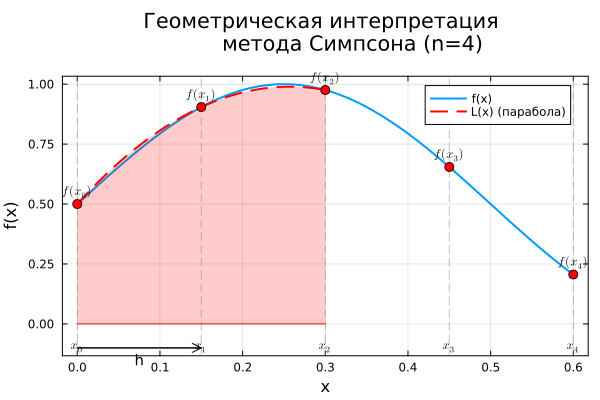

In [12]:
using Plots

function plot_simpson_interpretation(f, a, b, n)
    # Вычисляем точки разбиения
    h = (b - a) / n
    x = range(a, b, length=n+1)
    y = f.(x)
    
    # Создаем график 
    p = plot(f, a, b, linewidth=2, label="f(x)", legend=:topright, title="Геометрическая интерпретация 
        метода Симпсона (n=$n)
        
        ", xlabel="x", ylabel="f(x)", framestyle=:box)
 
    
    # Строим параболу через первые три точки
    if n >= 2
        # Коэффициенты параболы L(x) = ax^2 + bx + c
        A = [x[1]^2 x[1] 1; x[2]^2 x[2] 1; x[3]^2 x[3] 1]
        coeff = A \ y[1:3]
        parabola(x) = coeff[1]*x^2 + coeff[2]*x + coeff[3]
        
        # Рисуем параболу пунктиром
        xs = range(x[1], x[3], length=100)
        plot!(xs, parabola.(xs), linestyle=:dash, linewidth=2, color=:red, label="L(x) (парабола)")
        
        # Закрашиваем площадь под параболой
        plot!(xs, [0 for _ in xs], fillrange=parabola.(xs), fillalpha=0.2, color=:red, label="")
    end
    
    for i in 0:n
        vline!([x[i+1]], linestyle=:dash, color=:gray, alpha=0.5, label="") 
        scatter!([x[i+1]], [y[i+1]], markersize=5, color=:red, label="")
        annotate!(x[i+1], -0.1, text("\$x_{$i}\$", 8, :center))
        annotate!(x[i+1], y[i+1]+0.05, text("\$f(x_{$i})\$", 8, :center))
    end
    
    # Подпись шага h
    annotate!(x[1] + h/2, -0.15, text("h", 10, :center))
    plot!([x[1], x[2]], [-0.1, -0.1], arrow=true, color=:black, label="")
    
end


f(x) = 0.5 + sin(2π*x)/2  # Тестовая функция
plot_simpson_interpretation(f, 0, 0.6, 4)  # Четное число интервалов

## 18.3 Правило Рунге оценки точности численного интегрирования

Для вычисления определённого интеграла $\int_a^b f(x)dx$ применяется следующий подход. При разбиении интервала $[a,b]$ на $n$ равных частей с шагом $h = \frac{b-a}{n}$ и узлами $x_i = a + ih$, где $i = 0, 1, ..., n-1, n = b$, численный интеграл на отрезке $[x_i,x_{i+1}]$ выражается как:

$$
I_{i} = \int_{x_i}^{x_{i+1}} f(x)dx = I_{h,i} + R_i,
$$

где $I_{h,i}$ – любая из рассмотренных ранее квадратурных формул,
$R_i = C_i h^k + O(h^{k+1})$ представляет собой погрешность метода, а $k$ – порядок точности:
- $k=1$ для метода прямоугольников;
- $k=2$ для метода трапеций;
- $k=4$ для метода Симпсона.

Согласно правилу Рунге, оценка погрешности вычисляется через сравнение результатов с разными шагами. Если $I_{h,i}$ – значение, полученное с шагом $h$, а $I_{h/2,i}$ – с шагом $h/2$, то погрешность оценивается как:

$$
\epsilon_i \approx \frac{|I_{h,i} - I_{h/2,i}|}{2^k - 1}
$$

Критерий остановки итерационного процесса имеет вид:

$$
\epsilon_i < \tau,
$$

где $\tau$ – заданная допустимая погрешность. Если условие не выполняется, шаг интегрирования уменьшается вдвое ($h \rightarrow h/2$), и вычисления повторяются до достижения требуемой точности.

## 18.4 Квадратурные формулы Гаусса и Чебышёва

Формула Гаусса:

$$
\int_a^b f(t)dt = \frac{b-a}{2} \sum_{i=0}^{n} A_i \cdot f\left(\frac{b+a}{2} + \frac{a-b}{2}t_i\right)
$$

Коэффициенты для различных $n$:

| n | Узлы $t_i$                     | Веса $A_i$                              |
|---|--------------------------------|----------------------------------------|
| 2 | ±0.57735027                    | 1, 1                                    |
| 3 | ±0.77459667, 0                 | 5/9, 8/9, 5/9                           |
| 4 | ±0.86113631, ±0.33998104       | 0.34785484, 0.65214516                  |
| 5 | ±0.90617985, ±0.53846931, 0    | 0.23692688, 0.47862868, 0.56888889      |

Формула Чебышёва:

$$
\int_a^b f(t)dt = \frac{b-a}{2} \sum_{i=0}^{n}f\left(\frac{b+a}{2} + \frac{a-b}{2}t_i\right)
$$

Узлы для различных $n$:

| n | Узлы $t_i$                                                                |
|---|---------------------------------------------------------------------------|
| 2 | ±0.577350                                                                 |
| 3 | ±0.707107, 0                                                              |
| 4 | ±0.794654, ±0.187592                                                      |
| 5 | ±0.832498, ±0.374541, 0                                                   |
| 6 | ±0.866247, ±0.422519, ±0.266635                                           |
| 7 | ±0.883862, ±0.529657, ±0.323912, 0                                        |

In [13]:
# Подынтегральная функция: x^3 / sqrt(2 + cos(x))
function f(x)
    return x^3 / sqrt(2 + cos(x))
end

# Метод трапеций
function trapezoid(a, b, n)
    h = (b - a) / n
    integral = (f(a) + f(b)) / 2
    for i in 1:n-1
        integral += f(a + i*h)
    end
    return integral * h
end

# Вычисление интеграла методом трапеций с заданной точностью eps.Оценка точности проводится по правилу Рунг
function trapezoid_adaptive(a, b, eps)
    n = 5
    Ih = trapezoid(a, b, n)
    error = 100 * eps
    k = 1
    while error > eps
        n *= 2
        Ih2 = trapezoid(a, b, n)
        error = abs(Ih - Ih2) / 3  
        k += 1
        Ih = Ih2
    end
    
    return k, Ih
end

# Метод Симпсона
function simpson(a, b, m)
    n = 2*m  # Гарантируем четное число интервалов
    h = (b - a) / n
    integral = f(a) + f(b)
    p = 4
    
    for i in 1:n-1
        integral += p * f(a + i*h)
        p = 6 - p  
    end
    return integral * h / 3
end

function simpson_adaptive(a, b, eps)
    n = 3
    Ih = simpson(a, b, n)
    error = 100 * eps
    k = 1
    while error > eps
        n *= 2
        Ih2 = simpson(a, b, n)
        error = abs(Ih - Ih2) / 15  
        k += 1
        Ih = Ih2
    end
    return k, Ih
end

# Квадратура Гаусса (n=8)
function gauss(a, b)
    t = [-0.96028986, -0.79666648, -0.52553242, -0.18343464,
         0.18343464, 0.52553242, 0.79666648, 0.96028986]
    
    A = [0.10122854, 0.22238104, 0.31370664, 0.36268378,
         0.36268378, 0.31370664, 0.22238104, 0.10122854]
    
    integral = 0.0
    for i in 1:length(t)
        x = (a + b)/2 + (b - a)/2 * t[i]
        integral += A[i] * f(x)
    end
    
    return integral * (b - a)/2
end

# Квадратура Чебышёва (n=9)
function chebyshev(a, b)
    t = [-0.911589, -0.601019, -0.528762, -0.167906, 0.0,
         0.167906, 0.528762, 0.601019, 0.911589]
    
    integral = 0.0
    for i in 1:length(t)
        integral += f((a + b)/2 + (b - a)/2 * t[i])
    end
    
    return integral * (b - a)/length(t)
end

# Параметры интегрирования
a = 0.0
b = 2π  # Новый интервал интегрирования
eps = 1e-9

# Вычисления и вывод результатов
println("Метод трапеций:")
steps, result = trapezoid_adaptive(a, b, eps)
println("Значение интеграла = ", result)
println("Потребовалось $steps итераций\n")

println("Метод Симпсона:")
steps, result = simpson_adaptive(a, b, eps)
println("Значение интеграла = ", result)
println("Потребовалось $steps итераций\n")

println("Метод Гаусса (n=8):")
result = gauss(a, b)
println("Значение интеграла = ", result, "\n")

println("Метод Чебышёва (n=9):")
result = chebyshev(a, b)
println("Значение интеграла = ", result)

Метод трапеций:
Значение интеграла = 267.7824029347913
Потребовалось 18 итераций

Метод Симпсона:
Значение интеграла = 267.78240293511885
Потребовалось 8 итераций

Метод Гаусса (n=8):
Значение интеграла = 267.755196874095

Метод Чебышёва (n=9):
Значение интеграла = 267.9605088409476


## 18.5 Библиотеки для численного решения интегралов

В Julia существует несколько библиотек для численного интегрирования, каждая со своим синтаксисом и особенностями.

**QuadGK** (1D интегрирование) 

Назначение: Одномерные интегралы (включая бесконечные пределы).  
Метод: Адаптивный квадратурный метод Гаусса-Кронрода.  
Для получения дополнительной информации см. [документацию.](https://github.com/JuliaMath/QuadGK.jl)

In [28]:
using QuadGK

# ∫x² dx от 0 до 1 
result, err = quadgk(x -> x^2, 0, 1)
println("Результат: ", result, ", ошибка: ", err)

# ∫e^(-x²) dx от -∞ до ∞ 
result, _ = quadgk(x -> exp(-x^2), -Inf, Inf)
println("Результат: ", result)

Результат: 0.3333333333333333, ошибка: 0.0
Результат: 1.7724538509055137


**Cubature** (N-D интегрирование)

Назначение: Многомерные интегралы (2D, 3D, ...).  
Метод: Адаптивная квадратура.  
Для получения дополнительной информации см. [документацию.](https://github.com/JuliaMath/Cubature.jl)

In [1]:
using Cubature

# Двойной интеграл ∫∫(x*y) dx dy на [0,1]×[0,1] 
f(x) = x[1] * x[2]  # x[1] = x, x[2] = y
result, _ = hcubature(f, [0, 0], [1, 1])
println("Результат: ", result)

# Тройной интеграл ∫∫∫(x + y + z) dx dy dz на [0,1]³
f(x) = x[1] + x[2] + x[3]
result, err = hcubature(f, [0, 0, 0], [1, 1, 1])
println("Результат: ", result, ", ошибка: ", err)

Результат: 0.25
Результат: 1.4999999999999998, ошибка: 2.220446049250313e-16


**HCubature** (Оптимизированная N-D квадратура)

Назначение: Альтернатива Cubature с оптимизациями.  
Метод: Адаптивная квадратура (часто быстрее).  
Для получения дополнительной информации см. [документацию.](https://github.com/JuliaMath/HCubature.jl)

In [31]:
using HCubature

# ∫∫(sin(x) + cos(y)) dx dy на [0, π]×[0, π/2]
f(x) = sin(x[1]) + cos(x[2])
result, _ = hcubature(f, [0, 0], [π, π/2])
println("Результат: ", result)


Результат: 6.283185307185815
